<a href="https://colab.research.google.com/github/Shaleen708/02-Exploratory_data_analysis_with_sales_data_Spring_2026-/blob/main/Project2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 1. Stock Prediction:
 Question: How can I predict the stock price of a company using LSTM in a Jupyter notebook or any other tool?

In [ ]:
!pip install yfinance


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


In [45]:
data = yf.download('AAPL', start='2015-01-01', end='2024-12-31')

data.head()


/tmp/ipykernel_4042/600417494.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214893,24.682226,23.776353,24.671151,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


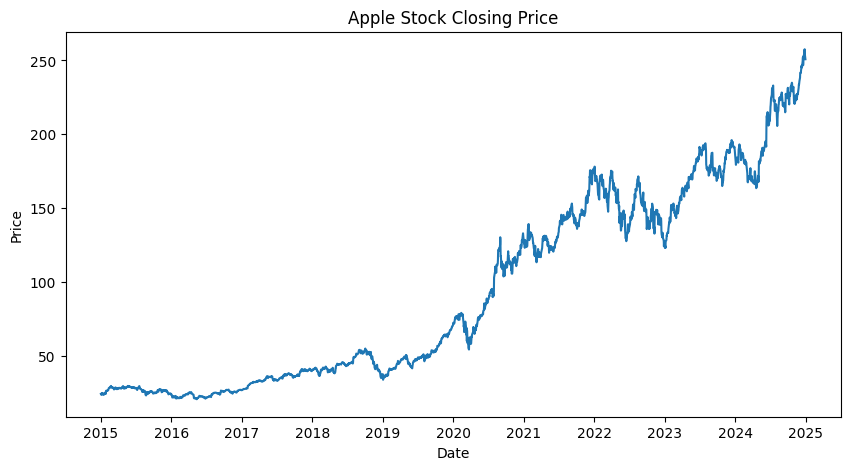

In [46]:
plt.figure(figsize=(10,5))

plt.plot(data['Close'])

plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()


In [47]:
closing_price = data[['Close']]


In [48]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price)


In [49]:
x_train = []
y_train = []

for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)


In [50]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(x_train.shape)

(2455, 60, 1)


In [51]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True,
               input_shape=(x_train.shape[1],1)))

model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))

model.add(Dropout(0.2))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [53]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.0155
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0022
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0017
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0019
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0017
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0016
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0014
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0015
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0014
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0013
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0013
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0012
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0012
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0012
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0013
Epoc

In [54]:
test_data = scaled_data[len(scaled_data)-len(x_train)-60:]

x_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)

In [55]:
x_test = np.reshape(x_test,
                    (x_test.shape[0],
                     x_test.shape[1],1))

In [56]:
predicted_prices = model.predict(x_test)

predicted_prices = scaler.inverse_transform(predicted_prices)

77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


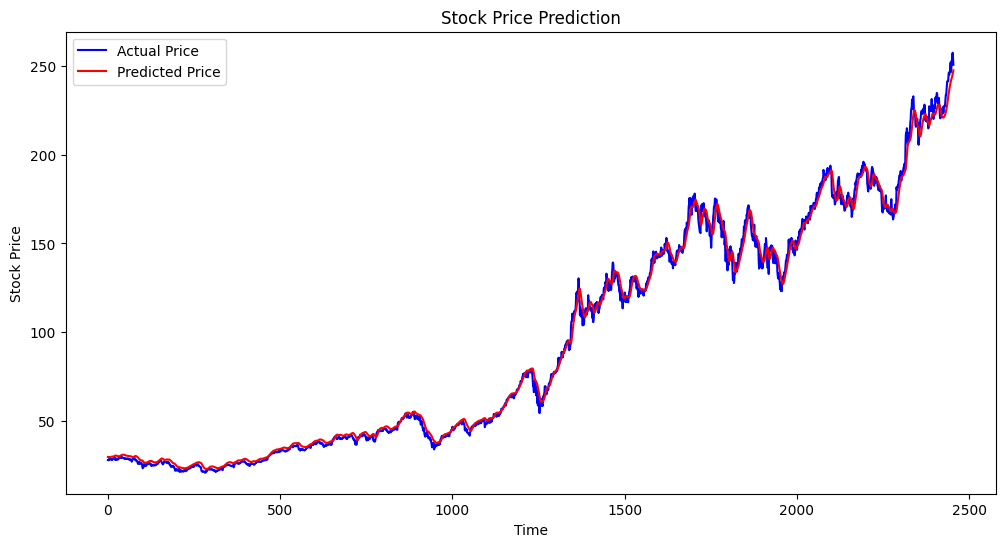

In [57]:
actual_prices = closing_price[-len(predicted_prices):].values

plt.figure(figsize=(12,6))

plt.plot(actual_prices, color='blue',
         label='Actual Price')

plt.plot(predicted_prices, color='red',
         label='Predicted Price')

plt.title("Stock Price Prediction")

plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [58]:
last_60_days = scaled_data[-60:]

last_60_days = np.reshape(last_60_days,
                          (1,60,1))

next_day = model.predict(last_60_days)

next_day = scaler.inverse_transform(next_day)

print("Predicted Next Day Price:",
      next_day[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Next Day Price: 248.0627


In [59]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    actual_prices,
    predicted_prices
)

print("Mean Squared Error:", mse)

Mean Squared Error: 14.796291634233738


In [60]:
model.save("stock_lstm_model.h5")

In [61]:
from tensorflow.keras.models import load_model

new_model = load_model("stock_lstm_model.h5")

In [62]:
last_60_days = scaled_data[-60:]

last_60_days = np.reshape(
    last_60_days,
    (1,60,1)
)

prediction = new_model.predict(last_60_days)

prediction = scaler.inverse_transform(prediction)

print("Predicted Next Day Price:",
      prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
Predicted Next Day Price: 248.0627


In [63]:
from google.colab import files

files.download("stock_lstm_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2. Titanic Classification: Question: How can I create a system to predict if a person will survive the Titanic sinking and identify key factors influencing survival like socio-economic status, age, and gender?

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Titanic-Dataset.csv to Titanic-Dataset.csv


{'Titanic-Dataset.csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
import pandas as pd
df = pd.read_csv("train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_4042/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [8]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_4042/3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [9]:
df.drop('Cabin', axis=1, inplace=True)

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [13]:
X = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df['Survived']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



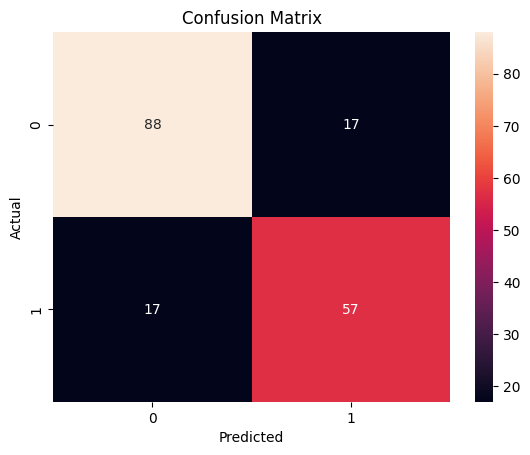

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

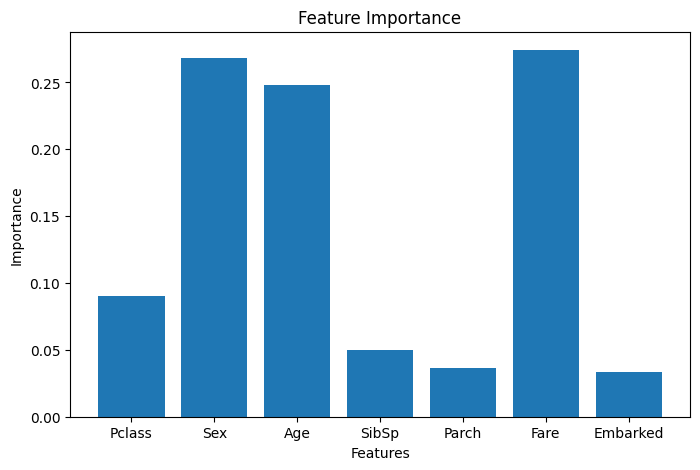

In [20]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [21]:
# Example:
# Pclass=1
# Sex=0 (female)
# Age=25
# SibSp=1
# Parch=0
# Fare=100
# Embarked=2

new_data = [[1,0,25,1,0,100,2]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
import joblib

joblib.dump(model, 'titanic_model.pkl')

['titanic_model.pkl']

3. **Number Recognisation**: Question: How can I create a Handwritten Digit Recognition system using the MNIST dataset with a Neural Network in a Jupyter notebook or any other tool?

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf



In [25]:
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
print(X_train.shape)
print(X_test.shape)


(60000, 28, 28)
(10000, 28, 28)


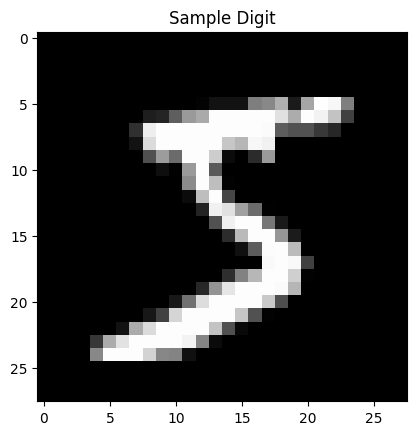

Label: 5


In [27]:
plt.imshow(X_train[0], cmap='gray')
plt.title("Sample Digit")
plt.show()

print("Label:", y_train[0])


In [28]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten


In [32]:
model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9294 - loss: 0.2443 - val_accuracy: 0.9597 - val_loss: 0.1326
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9697 - loss: 0.0999 - val_accuracy: 0.9747 - val_loss: 0.0820
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9780 - loss: 0.0705 - val_accuracy: 0.9772 - val_loss: 0.0737
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9833 - loss: 0.0535 - val_accuracy: 0.9782 - val_loss: 0.0741
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9857 - loss: 0.0438 - val_accuracy: 0.9736 - val_loss: 0.0924
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9886 - loss: 0.0345 - val_accuracy: 0.9783 - val_loss: 0.0743
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9787 - val_loss: 0.0781
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9920 - loss: 0.0242

In [35]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9776 - loss: 0.0897
Test Accuracy: 0.9775999784469604


In [36]:
prediction = model.predict(X_test)

print("Predicted Digit:", np.argmax(prediction[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted Digit: 7


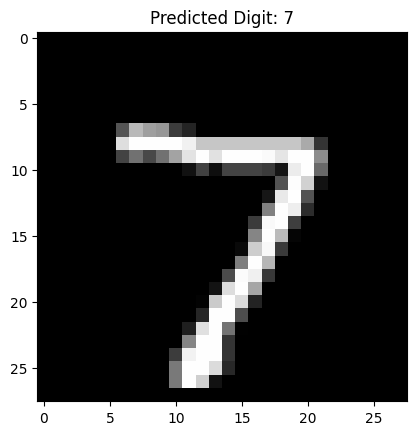

In [37]:
plt.imshow(X_test[0], cmap='gray')
plt.title("Predicted Digit: {}".format(np.argmax(prediction[0])))
plt.show()

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

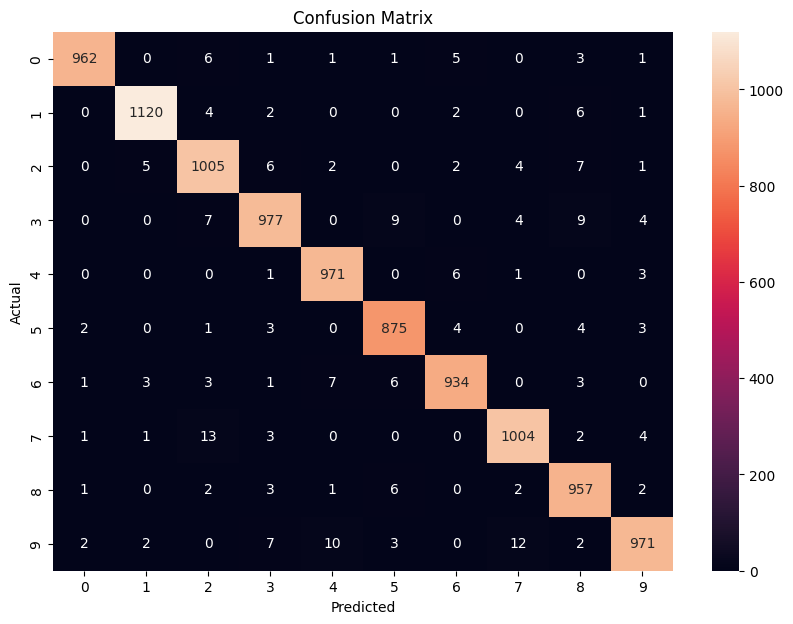

In [39]:
y_pred = np.argmax(prediction, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.99      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.97      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [41]:
model.save("digit_recognition_model.h5")

In [42]:
from tensorflow.keras.models import load_model

new_model = load_model("digit_recognition_model.h5")

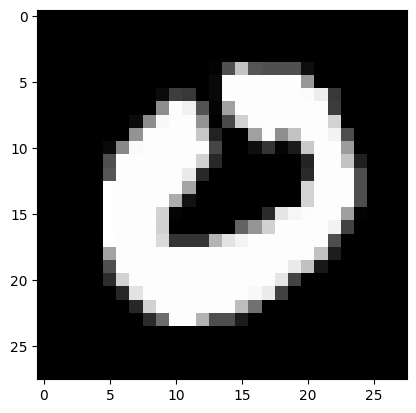

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Digit: 0


In [43]:
index = 25

plt.imshow(X_test[index], cmap='gray')
plt.show()

pred = model.predict(X_test[index].reshape(1,28,28))

print("Predicted Digit:", np.argmax(pred))